[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/breakpoints.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239469-lesson-2-breakpoints)

# Breakpoints

## 回顧

在 `human-in-the-loop` 的情境中，我們經常希望在 graph 執行的過程中就能看到它的輸出。

我們先前透過 streaming 為這件事打下了基礎。

## 目標

現在，讓我們來談談為什麼需要 `human-in-the-loop`：

(1) `Approval`（核准）- 我們可以中斷 agent，把 state 呈現給使用者，讓使用者決定是否接受某個動作

(2) `Debugging`（除錯）- 我們可以把 graph 倒帶，以重現或避開問題

(3) `Editing`（編輯）- 你可以修改 state

LangGraph 提供了多種取得或更新 agent state 的方式，用來支援各式各樣的 `human-in-the-loop` workflow。

首先，我們會介紹 [breakpoints](https://docs.langchain.com/oss/python/langgraph/interrupts#debugging-with-interrupts)，它提供了一種簡單的方式，讓 graph 在特定步驟停下來。

我們會示範這如何讓使用者進行 `approval`（核准）。

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk langgraph-prebuilt

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

## 用於人工核准的 Breakpoints

讓我們重新看一下在 Module 1 用過的那個簡單 agent。

假設我們很在意工具的使用：我們希望在 agent 使用任何工具之前，都先經過我們的核准。
 
我們需要做的，只是在 compile graph 時加上 `interrupt_before=["tools"]`，其中 `tools` 就是我們的 tools 節點。

這代表執行會在 `tools` 這個節點（也就是實際執行 tool call 的地方）之前被中斷。

In [2]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """將 a 與 b 相乘。

    Args:
        a: first int
        b: second int
    """
    return a * b

# 這會是一個 tool
def add(a: int, b: int) -> int:
    """將 a 與 b 相加。

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """將 a 除以 b。

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")
# 前提揭露（這個前提沒講，後面整個 tool calling 都是天書）：
# LLM 不會算數學，它只會「說」它想算。
# bind_tools 做的事只是把這三個函式的名字、參數型別、docstring 打包成一份「菜單」，
# 跟著每次提問一起送給 model 看。model 讀完菜單，回你的是一張「請求單」
#（tool call：我要點 multiply，a=2、b=3），不是 6。
# 真正把 2*3 算出來的，是 tools node 裡的那個 Python 函式——由 LangGraph 執行，不是 model。
# 推論：上面的 docstring 不是寫給人看的註解，它是 model 唯一讀得到的工具說明書。
llm_with_tools = llm.bind_tools(tools)

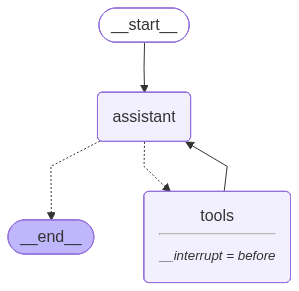

In [3]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node（節點）
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# 定義節點：這些節點負責實際的工作
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# 定義 edges：這些 edge 決定了控制流程
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # tools_condition 的真正邏輯只有三行：看 messages[-1] 有沒有 tool_calls，
    # 有 → 回傳字串 "tools"；沒有 → 回傳字串 "__end__"。
    # add_conditional_edges 就拿這個「回傳的字串」當作下一站 node 的名字去查表。
    # 所以 "__end__" 不是什麼特殊語法，它就是 END 這個常數的真面目（END == "__end__"）。
    #
    # 類比：餐廳服務生只聽客人最後講的那句話——
    #   「我要點菜」→ 單子送進廚房（tools）；「吃飽了」→ 結帳走人（END）。
    # 服務生自己不做菜。tools_condition 也一樣：它只決定往哪送，它不呼叫任何 tool。
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
# interrupt_before 的 before 是字面意思：進 tools node「之前」就停，
# tools 裡的函式一行都還沒執行。停的位置是 node 的門口，不是門內。
#
# 為什麼一定要有 checkpointer？因為「停下來」的本質是「存檔後離開」。
# 沒有存檔，停下來之後就無從恢復——這兩個參數是綁在一起的，不是兩個獨立選項。
#
# ⚠️ 踩雷：漏掉 checkpointer 不會報錯，它錯得很安靜。（已實測）
#    graph 照樣停在 tools 門口，但 state 沒存到任何地方，於是：
#    get_state() → ValueError: No checkpointer set
#    stream(None, ...) 續跑 → EmptyInputError
#    也就是：它停了，而且永遠醒不過來。
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# 顯示
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# Input（輸入）
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
# thread_id = 這次對話的「存檔名稱」。每跑完一個 node，LangGraph 就把 state 存成一個
# checkpoint 掛在這個 thread_id 底下，串成一條時間線。斷點之所以能續跑，靠的就是它。
thread = {"configurable": {"thread_id": "1"}}

# stream_mode="values" → 每個 node 跑完吐出「完整 state」；
# 對照組 "updates" → 只吐這個 node 改了什麼（差異）。這裡要完整 messages，所以用 values。
#
# ⚠️ 踩雷：這裡是整份 notebook 最騙人的地方——
# 這個 for 迴圈是「正常結束」的，不會拋任何 exception，畫面看起來就像 graph 跑完了。
# 實際上它只是停在 tools 的門口。「stream 結束」≠「graph 跑完」，
# 唯一的分辨方法是下一個 cell 的 state.next 空不空。
#
# 看輸出正好印證上面那個前提：畫面只有 Tool Calls: multiply, Args: a=2 b=3，看不到 6。
# 因為那是 LLM 開的請求單，6 這個數字此刻根本還不存在——tools 一行都還沒跑。
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_kN7VztrVU8GofwMrxVdJaxo4)
 Call ID: call_kN7VztrVU8GofwMrxVdJaxo4
  Args:
    a: 2
    b: 3


我們可以取得 state，並查看接下來要呼叫的節點。

這是一種很好的方式，可以看出 graph 已經被中斷了。

In [5]:
# next =「醒來之後要跑的下一站」。
# 停在 breakpoint 時它是 ('tools',)：非空，證明 tools 還沒跑，graph 只是暫停。
# 真的跑完時 next 是空 tuple ()。
# 這是分辨「停住」和「跑完」的唯一可靠方法——因為這兩件事在畫面上長得一模一樣。
state = graph.get_state(thread)
state.next

('tools',)

現在，來介紹一個很棒的小技巧。

當我們用 `None` 去 invoke graph 時，它就會直接從上一個 state checkpoint 繼續執行！

![breakpoints.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbae7985b747dfed67775d_breakpoints1.png)

為了清楚起見，LangGraph 會重新發出（re-emit）目前的 state，其中包含帶有 tool call 的 `AIMessage`。

接著它會繼續執行 graph 接下來的步驟，而這些步驟是從 tool 節點開始的。

我們會看到 tool 節點以這個 tool call 被執行，結果再被傳回 chat model，以產生我們的最終答案。

In [8]:
# 整個 module-3 最反直覺的一行：第一個參數傳 None 是「續跑」，不是「重跑」。
#
# 為什麼？None 的意思是「我沒有新的輸入要給你」，
# 於是 LangGraph 去這個 thread 的 checkpoint 把存檔讀回來，從斷點接著跑下去。
# 對照組：傳 dict（像上一個 cell 的 initial_input）＝「開新的一輪」，會再塞一則 HumanMessage。
#
# ⚠️ 踩雷：輸出的第一則又是那張一模一樣的 tool call 請求單，別以為是重跑了一次。
# 那是 LangGraph 續跑時會先把目前 state 重新吐一次（re-emit）；往下的 6 才是新跑出來的。
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_oFkGpnO8CuwW9A1rk49nqBpY)
 Call ID: call_oFkGpnO8CuwW9A1rk49nqBpY
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


現在，讓我們把這些整合起來，加入一個會接收使用者輸入、由使用者明確核准的步驟。

In [9]:
# Input（輸入）
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
# thread_id 從 "1" 換成 "2"：thread "1" 那個存檔已經跑完了（next 是空的），
# 拿它再跑只會接在舊對話後面。換一個 thread_id ＝ 開一個全新存檔從頭來過，
# 才能重現「停在 tools 門口」這個狀態，示範給人核准。
thread = {"configurable": {"thread_id": "2"}}

# 執行 graph，直到第一次中斷為止
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# 這一行就是 interrupt_before 的存在意義：
# 人在「請求單」階段就看到 LLM 想做什麼，而它還沒做。
# 講法：把 multiply 換成 delete_database(name="prod") 再看一次上面那個畫面，
#      你會很慶幸它停在請求單階段。
user_approval = input("Do you want to call the tool? (yes/no): ")

# 檢查是否核准
if user_approval.lower() == "yes":
    
    # 答 yes → 用 None 續跑，multiply 到這一刻才真的被執行，6 也是到這裡才存在。
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()
        
else:
    # 答 no → 什麼都不做，state 就永遠停在 tools 門口。
    # ⚠️ 踩雷：「取消」不等於「撤銷」。那張 tool call 請求單還躺在 checkpoint 裡，
    #    這個 thread 之後任何時候被 stream(None, thread) 叫醒，一樣會把 tool 執行下去。
    #    要真的作廢，得去改 state（下一課 state editing 的主題），不是靠這個 else。
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_tpHvTmsHSjSpYnymzdx553SU)
 Call ID: call_tpHvTmsHSjSpYnymzdx553SU
  Args:
    a: 2
    b: 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_tpHvTmsHSjSpYnymzdx553SU)
 Call ID: call_tpHvTmsHSjSpYnymzdx553SU
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


### 搭配 LangGraph API 的 Breakpoints

**⚠️ 注意**

自從拍攝這些影片以來，我們已經更新了 Studio，現在它可以在本機執行並透過瀏覽器存取。這是執行 Studio 的建議方式，取代影片中所示的桌面版 App。它現在叫做 _LangSmith Studio_，而不再是 _LangGraph Studio_。詳細的設定說明可以在課程一開始的「Getting Setup」指南中找到。你可以在[這裡](https://docs.langchain.com/langsmith/studio)看到 Studio 的說明，並在[這裡](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)找到本機部署的詳細資訊。  
若要啟動本機開發伺服器，請在這個 module 的 `/studio` 目錄下，於終端機執行下列指令：

```
langgraph dev
```

你應該會看到以下輸出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打開你的瀏覽器，前往上面顯示的 **Studio UI** URL。

LangGraph API [支援 breakpoints](https://docs.langchain.com/langsmith/add-human-in-the-loop)。

In [1]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

In [2]:
# 這是本機開發伺服器的 URL
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

如上所示，我們可以在 compile 那個於 Studio 中執行的 graph 時加上 `interrupt_before=["node"]`。

不過，搭配 API 時，你也可以直接把 `interrupt_before` 傳給 stream 方法。

In [10]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}
# 對照本機版：thread 是自己捏的 dict {"configurable": {"thread_id": "1"}}。
# SDK 版改由伺服器發一個 thread 給你，存檔也存在伺服器上，不在這個 notebook 的記憶體裡。
thread = await client.threads.create()
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=initial_input,
    stream_mode="values",
    # 對照組——同一件事，兩種決定時機：
    #   本機版：compile(interrupt_before=["tools"]) → graph 一建好就定死，每次跑都會停。
    #   SDK 版：interrupt_before 是「每次 run 才傳」→ 同一個已經部署好的 graph，
    #           這次 run 要停、下次 run 不停，由呼叫端當場決定。
    interrupt_before=["tools"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '2a3b1e7a-f6d9-44c2-a4b4-b7f67aa3691c', 'example': False}
--------------------------------------------------
Receiving new event of type: values...
{'content': '', 'additional_kwargs': {'tool_calls': [{'id': 'call_ElnkVOf1H80dlwZLqO0PQTwS', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 18, 'prompt_tokens': 134, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb9dce56a8', 'finish_reason': 't

現在，我們可以像之前一樣，透過傳入 `thread_id` 以及把 `None` 當作 input，從 breakpoint 繼續往下執行！

In [11]:
async for chunk in client.runs.stream(
    thread["thread_id"],
    "agent",
    # input=None 和本機版的 stream(None, thread, ...) 是同一個道理：
    # 沒有新輸入 → 從 checkpoint 接著跑。差別只在存檔放在伺服器上，
    # 靠第一個參數 thread["thread_id"] 認出要接哪一份存檔。
    input=None,
    stream_mode="values",
    interrupt_before=["tools"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)

Receiving new event of type: metadata...
--------------------------------------------------
Receiving new event of type: values...
{'content': '', 'additional_kwargs': {'tool_calls': [{'id': 'call_ElnkVOf1H80dlwZLqO0PQTwS', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 18, 'prompt_tokens': 134, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eb9dce56a8', 'finish_reason': 'tool_calls', 'logprobs': None}, 'type': 'ai', 'name': None, 'id': 'run-89ee14dc-5f46-4dd9-91d9-e922c4a23572-0', 'example': False, 'tool_calls': [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_ElnkVOf1H80dlwZLqO0PQTwS', 'type': 'tool_call'}], 'invalid_tool_